In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Path to the exported Sentinel-2 composite
x_train_path = "/content/drive/MyDrive/GEE_Exports/tsoparidhi2_x_train_image.tif"

In [ ]:
import zipfile
import geopandas as gpd

In [ ]:
shapefile_path = "/content/drive/MyDrive/GEE_Exports/Shapefiles/tsoparidhi2/tsoparidhi2_lake.shp"
gdf = gpd.read_file(shapefile_path)
print(gdf.head())

   id       layer                                               path  \
0   1      tsoaoi                                         tsoaoi.shp   
1   1  tsowithaoi  C:/Users/traza/Documents/clipaoi/tsowithaoi/ts...   

                                            geometry  
0  POLYGON ((8640018.925 3843238.259, 8640761.784...  
1  POLYGON ((8640297.865 3843015.264, 8640301.838...  


In [ ]:
!pip install rasterio

In [ ]:
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_origin

In [ ]:
# Open the x_train GeoTIFF
with rasterio.open(x_train_path) as src:
    meta = src.meta.copy()
    transform = src.transform
    out_shape = (src.height, src.width)

# Burn polygons into raster (1 = lake, 0 = non-lake)
shapes = [(geom, 1) for geom in gdf.geometry]

mask = rasterize(
    shapes,
    out_shape=out_shape,
    transform=transform,
    fill=0,
    dtype='uint8'
)

In [ ]:
y_train_path = "/content/drive/MyDrive/GEE_Exports/tsoparidhi2_y_train.tif"

In [ ]:
with rasterio.open(y_train_path, 'w', **meta) as dst:
    dst.write(mask, 1)

print("Raster mask saved at:", y_train_path)

Raster mask saved at: /content/drive/MyDrive/GEE_Exports/tsoparidhi2_y_train.tif


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Load rasters
with rasterio.open(x_train_path) as xsrc:
    x_img = xsrc.read([4,3,2])  # RGB
with rasterio.open(y_train_path) as ysrc:
    y_img = ysrc.read(1)

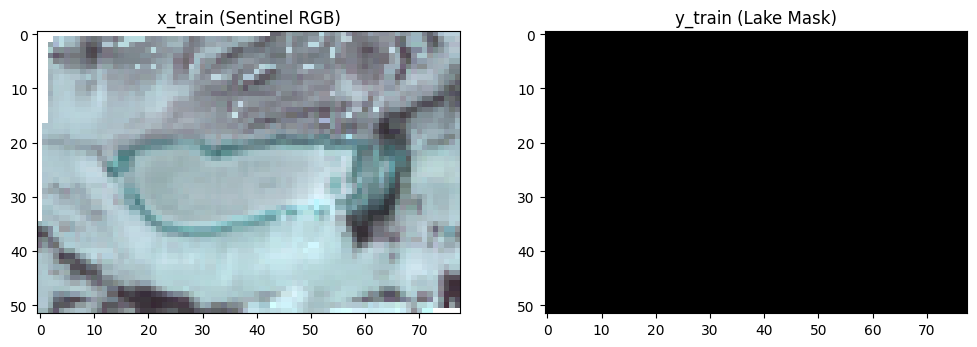

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].imshow(x_img.transpose(1,2,0))
ax[0].set_title("x_train (Sentinel RGB)")
ax[1].imshow(y_img, cmap="gray")

ax[1].set_title("y_train (Lake Mask)")
plt.show()